# Gaussian Mixture Models (GMM) para clustering

Este notebook presenta una introducción didáctica a los Gaussian Mixture Models como alternativa al clustering basado en centroides, como K-Means, y al clustering jerárquico. La idea central es simple: en lugar de asumir que cada cluster se representa por un centro único, GMM supone que los datos dentro de cada grupo provienen de una distribución gaussiana, y luego estima la probabilidad de pertenencia de cada observación a cada componente.

Desde una perspectiva pedagógica, GMM es especialmente útil porque conecta dos ideas fundamentales: la estructura de los datos y la elección del número de grupos. Como veremos, la visualización ayuda a formular hipótesis, pero la decisión final sobre $k$ debe apoyarse en criterios estadísticos. En este notebook, por tanto, comparamos varias soluciones con distintos valores de $k$ y discutimos qué información aportan las métricas internas y los criterios de información.

Los tres ejemplos que se muestran —Iris, Old Faithful y Wholesale Customers— sirven como casos de estudio complementarios: uno clásico de clasificación y separación de especies, uno de estructura bimodal muy clara, y uno de segmentación comercial con variables de gasto. Juntos permiten observar cómo GMM se adapta a distintos tipos de datos y cómo debe interpretarse la solución final.

Referencias web consultadas:
- UCI Iris: https://archive.ics.uci.edu/dataset/53/iris
- Ejemplos de seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
- R datasets / Old Faithful: https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv
- UCI Wholesale Customers: https://archive.ics.uci.edu/dataset/292/wholesale+customers


In [30]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEMILLA = 42
RANGO_K = range(2, 11)


def interpretar_seleccion_k(resultados, nombre_dataset):
    mejor_k_aic = int(resultados.loc[resultados['aic'].idxmin(), 'k'])
    mejor_k_bic = int(resultados.loc[resultados['bic'].idxmin(), 'k'])
    mejor_k_silhouette = int(resultados.loc[resultados['silhouette'].idxmax(), 'k'])
    mejor_k_ch = int(resultados.loc[resultados['calinski_harabasz'].idxmax(), 'k'])
    mejor_k_db = int(resultados.loc[resultados['davies_bouldin'].idxmin(), 'k'])

    print(f'\nDataset: {nombre_dataset}')
    print(f'- BIC recomienda k={mejor_k_bic}')
    print(f'- AIC recomienda k={mejor_k_aic}')
    print(f'- Silhouette recomienda k={mejor_k_silhouette}')
    print(f'- Calinski-Harabasz recomienda k={mejor_k_ch}')
    print(f'- Davies-Bouldin recomienda k={mejor_k_db}')
    print('- Interpretación: en GMM, BIC suele ser la regla principal porque penaliza la complejidad del modelo. AIC, aunque útil como referencia, tiende a favorecer soluciones más complejas. Las métricas internas ayudan a describir la calidad de la separación, pero no sustituyen la elección estadística basada en el criterio de información.')

    return {
        'aic': mejor_k_aic,
        'bic': mejor_k_bic,
        'silhouette': mejor_k_silhouette,
        'calinski_harabasz': mejor_k_ch,
        'davies_bouldin': mejor_k_db,
    }


def evaluar_clustering(X_data, etiquetas):
    return {
        'silhouette': silhouette_score(X_data, etiquetas),
        'calinski_harabasz': calinski_harabasz_score(X_data, etiquetas),
        'davies_bouldin': davies_bouldin_score(X_data, etiquetas),
    }


def resumir_clusters(df_original, etiquetas):
    resumen = df_original.copy()
    resumen['cluster'] = etiquetas
    return resumen.groupby('cluster').mean(numeric_only=True).round(2)


def graficar_resultados_2d(df_2d, etiquetas, x_col, y_col, titulo):
    df_plot = df_2d[[x_col, y_col]].copy()
    df_plot['cluster'] = etiquetas
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_plot, x=x_col, y=y_col, hue='cluster', palette='tab10', s=60, alpha=0.8)
    plt.title(titulo)
    plt.tight_layout()


def graficar_componentes_gaussianas(X_data, modelo, x_col, y_col, titulo):
    plt.figure(figsize=(8, 6))
    etiquetas = modelo.predict(X_data)
    df_plot = pd.DataFrame(X_data, columns=[x_col, y_col])
    df_plot['cluster'] = etiquetas
    sns.scatterplot(data=df_plot, x=x_col, y=y_col, hue='cluster', palette='tab10', s=60, alpha=0.8)
    plt.title(titulo)
    plt.tight_layout()


## 1. Carga y comprensión del dataset

Usamos el dataset Iris como ejemplo clásico de clustering. Aunque tiene etiquetas reales, aquí las tratamos solo como referencia para evaluar si GMM recupera grupos naturales.


In [31]:
iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

libros = pd.DataFrame({
    'dataset': ['Iris'],
    'fuente': ['UCI / sklearn'],
    'observaciones': [X.shape[0]],
    'variables': [X.shape[1]],
    'clases_reales': [len(np.unique(y))],
})

display(libros)
display(X.head())
print(iris.DESCR.split('\n')[0])

,dataset,fuente,observaciones,variables,clases_reales
0,Iris,UCI / sklearn,150,4,3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


.. _iris_dataset:


## 2. Preparación de variables

Como GMM también depende de distancias y covarianzas, primero estandarizamos las variables numéricas. La visualización se hace con dos variables originales estandarizadas para facilitar la interpretación.


Variables estandarizadas para GMM.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


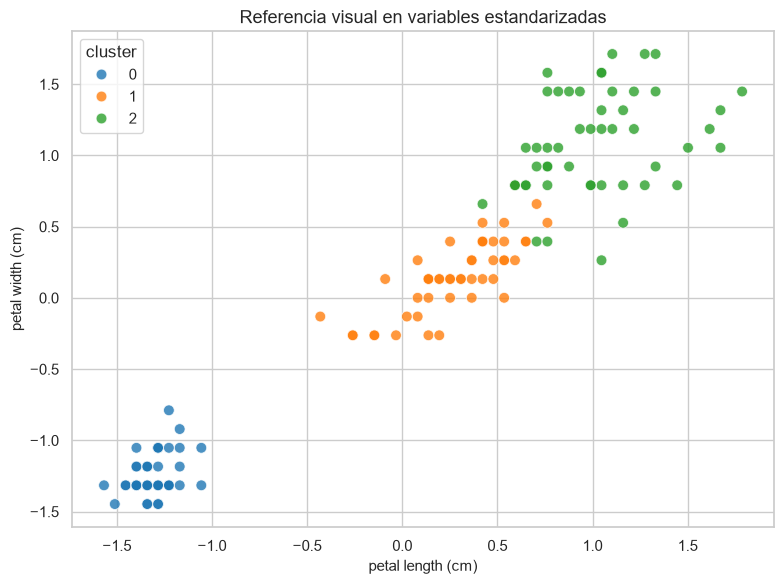

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Variables estandarizadas para GMM.')
display(X_scaled_df.head())

graficar_resultados_2d(X_scaled_df, y, 'petal length (cm)', 'petal width (cm)', 'Referencia visual en variables estandarizadas')


## 3. Selección de k y evaluación de clustering

La comparación de distintas soluciones con diferente número de componentes es el núcleo del análisis en GMM. No se trata solo de ajustar un modelo con un valor de $k$ arbitrario, sino de decidir cuál de las posibles particiones captura mejor la estructura subyacente del conjunto sin introducir complejidad innecesaria.

Para ello usamos métricas internas como silhouette, Calinski-Harabasz y Davies-Bouldin. Cada una responde a una pregunta distinta:
- silhouette mide qué tan bien separados están los clusters;
- Calinski-Harabasz compara la separación entre grupos con la dispersión dentro de cada grupo;
- Davies-Bouldin intenta resumir la compactación y la separación global.

Sin embargo, en GMM la regla decisiva suele ser BIC. AIC se incluye como referencia, pero suele ser menos conservador y tiende a favorecer soluciones más complejas. En un contexto de mezcla gaussiana, esto es crucial: un modelo con demasiados componentes puede describir el ruido con mucha precisión, pero perder claridad interpretativa y robustez estadística.

La lección pedagógica es clara: las métricas internas ayudan a describir la calidad de la partición, pero la elección final de $k$ debe apoyarse en un criterio que penalice la complejidad excesiva. Por eso, en este notebook, la solución final se selecciona con BIC y se usa como criterio principal para la interpretación del modelo.


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,2,707.4006,794.7090,0.5818,251.3493,0.5933
1,3,708.7226,841.1905,0.4751,141.2315,0.8867
2,4,671.6734,849.3009,0.2310,138.8946,1.3220
3,5,678.7507,901.5377,0.1729,127.1599,1.3302
4,6,700.6620,968.6086,0.1899,138.1896,1.3843
5,7,642.1531,955.2592,0.0653,84.3716,1.7031
6,8,667.8037,1026.0693,0.1740,105.1888,1.4811
7,9,725.9263,1129.3514,0.2645,148.3064,1.0918
8,10,651.8233,1100.4080,0.1532,106.4591,1.4912



Dataset: Iris
- BIC recomienda k=2
- AIC recomienda k=7
- Silhouette recomienda k=2
- Calinski-Harabasz recomienda k=2
- Davies-Bouldin recomienda k=2
- Interpretación: en GMM, BIC suele ser la regla principal porque penaliza la complejidad del modelo. AIC, aunque útil como referencia, tiende a favorecer soluciones más complejas. Las métricas internas ayudan a describir la calidad de la separación, pero no sustituyen la elección estadística basada en el criterio de información.

Elección pedagógica para Iris: se usa BIC como criterio principal y se toma k=2.
Esto significa que, aunque AIC o la silueta puedan sugerir otra solución, la decisión final prioriza la parsimonia y la capacidad explicativa del modelo.


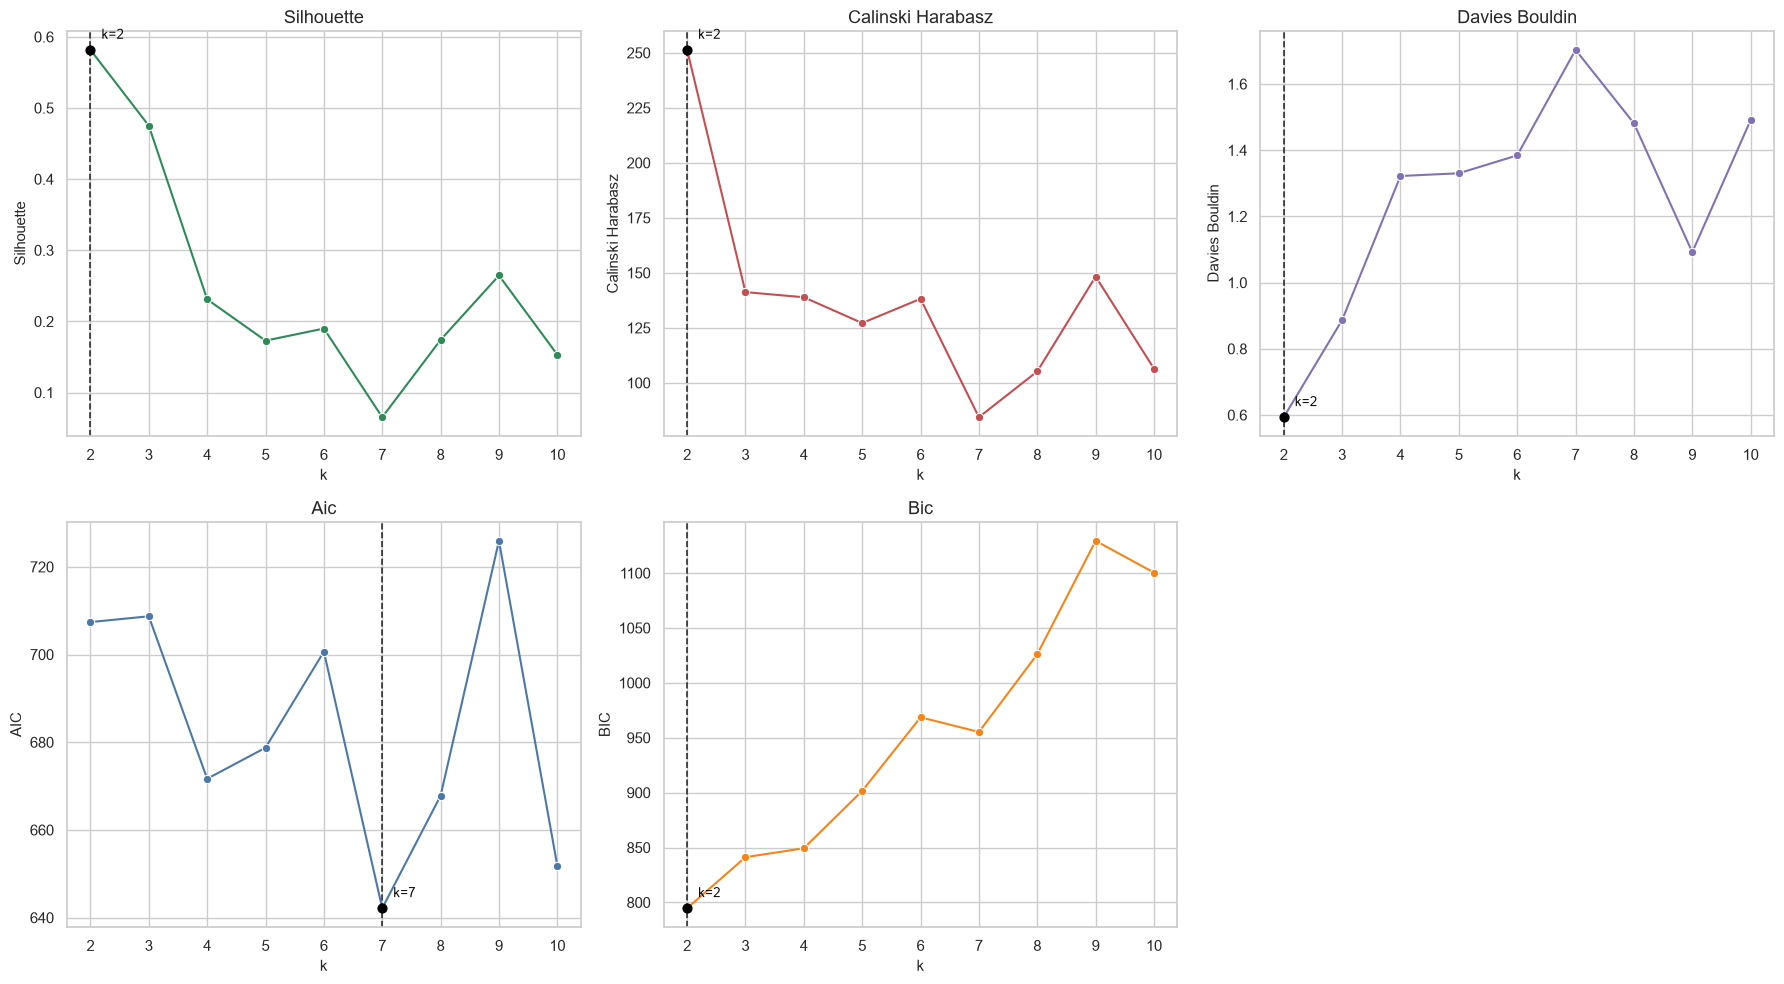

In [33]:
resultados_k = []

for k in RANGO_K:
    modelo = GaussianMixture(n_components=k, random_state=SEMILLA)
    etiquetas = modelo.fit_predict(X_scaled)
    metricas = evaluar_clustering(X_scaled, etiquetas)
    resultados_k.append({
        'k': k,
        'aic': modelo.aic(X_scaled),
        'bic': modelo.bic(X_scaled),
        **metricas,
    })

resultados_k = pd.DataFrame(resultados_k)
display(resultados_k.round(4))

seleccion_iris = interpretar_seleccion_k(resultados_k, 'Iris')
mejor_k_aic = seleccion_iris['aic']
mejor_k_bic = seleccion_iris['bic']
mejor_k = mejor_k_bic

print(f'\nElección pedagógica para Iris: se usa BIC como criterio principal y se toma k={mejor_k}.')
print('Esto significa que, aunque AIC o la silueta puedan sugerir otra solución, la decisión final prioriza la parsimonia y la capacidad explicativa del modelo.')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
color_map = {
    'silhouette': '#2e8b57',
    'calinski_harabasz': '#c44e52',
    'davies_bouldin': '#8172b3',
    'aic': '#4c78a8',
    'bic': '#f58518',
}

for ax, metrica in [
    (axes[0, 0], 'silhouette'),
    (axes[0, 1], 'calinski_harabasz'),
    (axes[0, 2], 'davies_bouldin'),
    (axes[1, 0], 'aic'),
    (axes[1, 1], 'bic')
]:
    if metrica in ['silhouette', 'calinski_harabasz']:
        mejor_k_metrica = int(resultados_k.loc[resultados_k[metrica].idxmax(), 'k'])
    else:
        mejor_k_metrica = int(resultados_k.loc[resultados_k[metrica].idxmin(), 'k'])

    sns.lineplot(data=resultados_k, x='k', y=metrica, marker='o', ax=ax, color=color_map[metrica])
    valor = float(resultados_k.loc[resultados_k['k'] == mejor_k_metrica, metrica].iloc[0])
    ax.axvline(mejor_k_metrica, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.scatter([mejor_k_metrica], [valor], color='black', s=40, zorder=5)
    ax.annotate(f'k={mejor_k_metrica}', xy=(mejor_k_metrica, valor), xytext=(8, 8), textcoords='offset points', fontsize=9, color='black')
    ax.set_title(metrica.replace('_', ' ').title())
    ax.set_xlabel('k')
    ax.set_ylabel(metrica.upper() if metrica in ['aic', 'bic'] else metrica.replace('_', ' ').title())

axes[1, 2].axis('off')
plt.tight_layout()


## 4. Modelo final e interpretación

Una vez que se ha comparado la familia de modelos para distintos valores de $k$, la siguiente etapa no es solo ajustar el mejor modelo, sino interpretarlo. Un análisis de resultados serio debe responder dos preguntas: ¿qué estructura de grupos está detectando el modelo? y ¿por qué esa partición es más razonable que otra?

En el caso de Iris, la forma del conjunto sugiere una separación más clara entre algunos grupos y una mayor superposición entre otros. GMM no impone una partición rígida como K-Means; en cambio, estima densidades gaussianas y asigna probabilidades de pertenencia. Esto permite que el análisis sea más matizado: un cluster puede ser muy compacto y bien definido, mientras otro refleja una zona de transición o de mayor variabilidad.

La interpretación final debe combinar dos tipos de evidencia: la evidencia estadística de la elección de $k$ y la evidencia descriptiva del perfil de los clusters. El primero responde a la pregunta “¿cuántos grupos son razonables?”, y el segundo responde a “¿qué caracteriza a cada uno de esos grupos?”.

En este notebook se sigue precisamente ese flujo, y la elección final se toma con BIC, porque representa un equilibrio entre ajuste y parsimonia: un modelo más complejo no siempre es mejor si la mejora en ajuste no compensa el costo adicional de introducir más componentes.


Perfil promedio por cluster:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.26,2.87,4.91,1.68
1,5.01,3.43,1.46,0.25


Cruce cluster vs clase real:


clase_real,0,1,2
cluster,,,
0,0,50,50
1,50,0,0



Interpretación del resultado en Iris:
- El modelo final usa k=2, elegida por BIC.
- Cada cluster representa una región de densidad estimada en el espacio de las variables originales.
- El cruce con la clase real ayuda a ver si los grupos gaussianos capturan patrones biológicos o si la mezcla es más artificial.
- Cuando un cluster reúne casi exclusivamente una especie, la partición está capturando una estructura natural. Si la mezcla se reparte entre varias especies, entonces el modelo está encontrando una separación más geométrica que taxonómica.


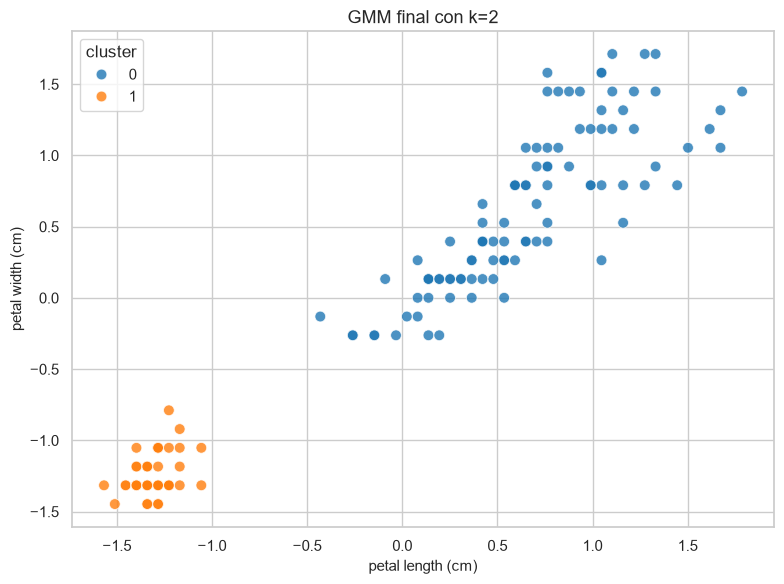

In [34]:
modelo_final = GaussianMixture(n_components=mejor_k, random_state=SEMILLA)
etiquetas = modelo_final.fit_predict(X_scaled)

perfil_cluster = resumir_clusters(X, etiquetas)
indices_cluster = pd.DataFrame({'cluster': etiquetas, 'clase_real': y})
cruce = pd.crosstab(indices_cluster['cluster'], indices_cluster['clase_real'])

print('Perfil promedio por cluster:')
display(perfil_cluster)
print('Cruce cluster vs clase real:')
display(cruce)

print('\nInterpretación del resultado en Iris:')
print(f'- El modelo final usa k={mejor_k}, elegida por BIC.')
print('- Cada cluster representa una región de densidad estimada en el espacio de las variables originales.')
print('- El cruce con la clase real ayuda a ver si los grupos gaussianos capturan patrones biológicos o si la mezcla es más artificial.')
print('- Cuando un cluster reúne casi exclusivamente una especie, la partición está capturando una estructura natural. Si la mezcla se reparte entre varias especies, entonces el modelo está encontrando una separación más geométrica que taxonómica.')


graficar_resultados_2d(X_scaled_df, etiquetas, 'petal length (cm)', 'petal width (cm)', f'GMM final con k={mejor_k}')


## 5. Conclusiones

- GMM es una herramienta natural para modelar agrupaciones que no se representan bien por centroides rígidos.
- La elección del número de componentes no debe basarse en una sola métrica ni en la intuición visual del gráfico; requiere un criterio estadístico y un análisis de la complejidad del modelo.
- En este contexto, BIC suele ser la regla más apropiada para GMM, mientras que AIC sirve como referencia útil pero más permisiva.
- Las métricas internas ofrecen señales interpretables sobre la separación y compactación del clustering, pero su valor es complementario, no sustituto, del criterio de información.
- El cruce con la clase real (cuando existe) aporta contexto interpretativo: ayuda a decidir si los grupos formados coinciden con patrones naturales o con particiones puramente geométricas.
- La preparación de variables, especialmente la estandarización y, en algunos casos, transformaciones como log1p, es esencial para que las densidades gaussianas queden bien definidas y comparables.

En resumen, GMM no es simplemente una alternativa a K-Means; es un marco probabilístico para describir la estructura de los datos y decidir cuántos grupos resultan razonables de acuerdo con la evidencia disponible.


## 6. Old Faithful Geyser: segundo ejemplo clásico de clustering

El dataset Old Faithful registra la duración de las erupciones y el tiempo de espera hasta la siguiente erupción del géiser en Yellowstone. Es un ejemplo clásico en la literatura de clustering y aparece en la documentación de R como un conjunto de 272 observaciones y 2 variables: `eruptions` y `waiting`.

Fuente web consultada:
- R documentation: https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/faithful.html
- CSV público de Rdatasets: https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv


,dataset,fuente,observaciones,variables
0,Old Faithful,R datasets / Rdatasets,272,2


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


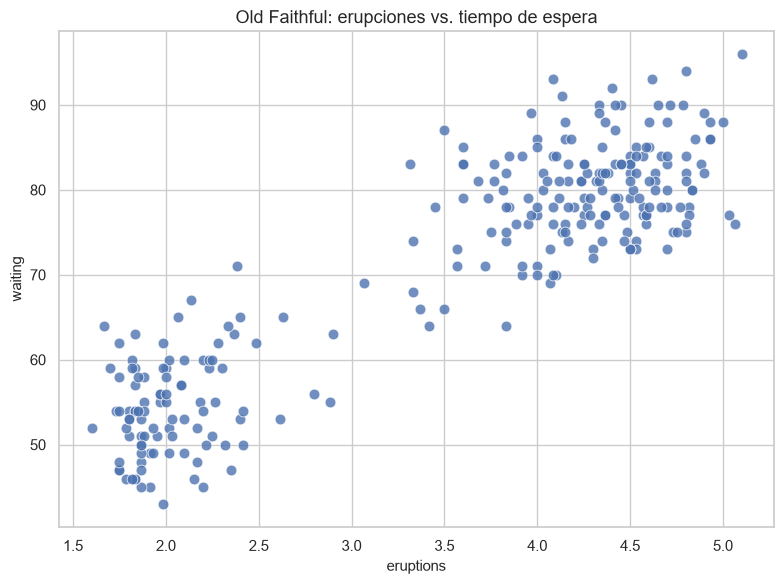

In [35]:
geyser = pd.read_csv('https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv')
geyser = geyser.drop(columns=['rownames'])
geyser_numerico = geyser[['eruptions', 'waiting']].copy()

conteo_geyser = pd.DataFrame({
    'dataset': ['Old Faithful'],
    'fuente': ['R datasets / Rdatasets'],
    'observaciones': [geyser.shape[0]],
    'variables': [geyser_numerico.shape[1]],
})

display(conteo_geyser)
display(geyser.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=geyser, x='eruptions', y='waiting', ax=ax, s=60, alpha=0.8, color='#4c72b0')
ax.set_title('Old Faithful: erupciones vs. tiempo de espera')
plt.tight_layout()

### Preparación, estandarización y selección de k

Como en el ejemplo de Iris, estandarizamos las variables antes de aplicar GMM y luego comparamos varios valores de $k$ con métricas internas. La diferencia aquí es que el patrón visual ya sugiere dos grupos muy marcados, por lo que el diagnóstico no debe centrarse solo en la apariencia, sino en si el modelo encuentra esa separación de forma estable cuando se compara varias soluciones.

En Old Faithful, el criterio BIC suele reforzar la intuición de que $k=2$ es la solución más económica y más interpretable. Esto resulta especialmente pedagógico: el modelo no solo “encuentra dos grupos”, sino que además lo hace con una justificación estadística coherente con la forma en que los datos se distribuyen.


Variables estandarizadas para Old Faithful.


,eruptions,waiting
0,0.098499,0.597123
1,-1.481459,-1.245181
2,-0.135861,0.228663
3,-1.057503,-0.655644
4,0.917443,1.039277


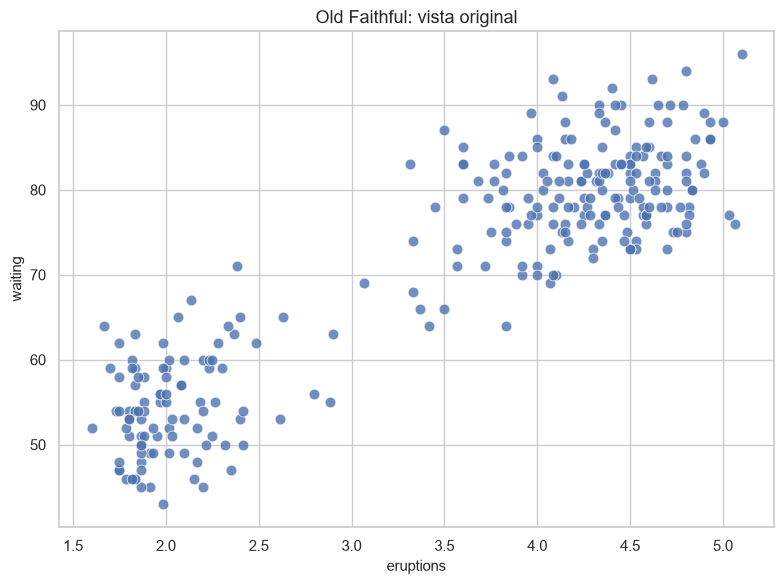

In [36]:
scaler_geyser = StandardScaler()
X_geyser = scaler_geyser.fit_transform(geyser_numerico)
X_geyser_df = pd.DataFrame(X_geyser, columns=geyser_numerico.columns)

print('Variables estandarizadas para Old Faithful.')
display(X_geyser_df.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=geyser_numerico, x='eruptions', y='waiting', s=60, alpha=0.8, color='#4c72b0')
plt.title('Old Faithful: vista original')
plt.tight_layout()


### Lectura de negocio

El patrón de Old Faithful suele separarse en dos comportamientos claros: erupciones cortas con esperas cortas y erupciones largas con esperas largas. GMM captura esa separación modelando dos densidades gaussianas distintas, lo que lo convierte en un ejemplo muy útil para explicar segmentación no supervisada en dos variables.


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,2,792.9216,832.5854,0.7460,1574.5548,0.3377
1,3,798.0638,859.3624,0.4645,1060.1263,0.9114
2,4,797.4865,880.4199,0.4585,922.8790,0.8631
3,5,781.1065,885.6747,0.2938,776.9968,1.2831
4,6,783.9286,910.1317,0.3060,752.9045,1.1569
5,7,796.9260,944.7639,0.3442,872.8667,0.9564
6,8,804.6393,974.1120,0.3514,904.5698,0.8982
7,9,813.9671,1005.0746,0.3393,861.6255,0.8924
8,10,803.8363,1016.5786,0.3433,815.2919,0.8878



Dataset: Old Faithful
- BIC recomienda k=2
- AIC recomienda k=5
- Silhouette recomienda k=2
- Calinski-Harabasz recomienda k=2
- Davies-Bouldin recomienda k=2
- Interpretación: en GMM, BIC suele ser la regla principal porque penaliza la complejidad del modelo. AIC, aunque útil como referencia, tiende a favorecer soluciones más complejas. Las métricas internas ayudan a describir la calidad de la separación, pero no sustituyen la elección estadística basada en el criterio de información.

Elección pedagógica para Old Faithful: se usa BIC como criterio principal y se toma k=2.
En este caso, la intuición visual y la evidencia estadística coinciden: dos componentes describen bien la estructura del sistema.
Perfil promedio por cluster en Old Faithful:


,eruptions,waiting
cluster,,
0,4.29,79.99
1,2.04,54.49



Interpretación del resultado:
- El patrón esperado de Old Faithful es un comportamiento bimodal: erupciones cortas con espera corta y erupciones largas con espera larga.
- GMM captura esa estructura como dos densidades gaussianas con distinta ubicación y dispersión.
- El hecho de que BIC favorezca k=2 es una señal de que esa partición es relativamente parsimonia y muy informativa para los datos.


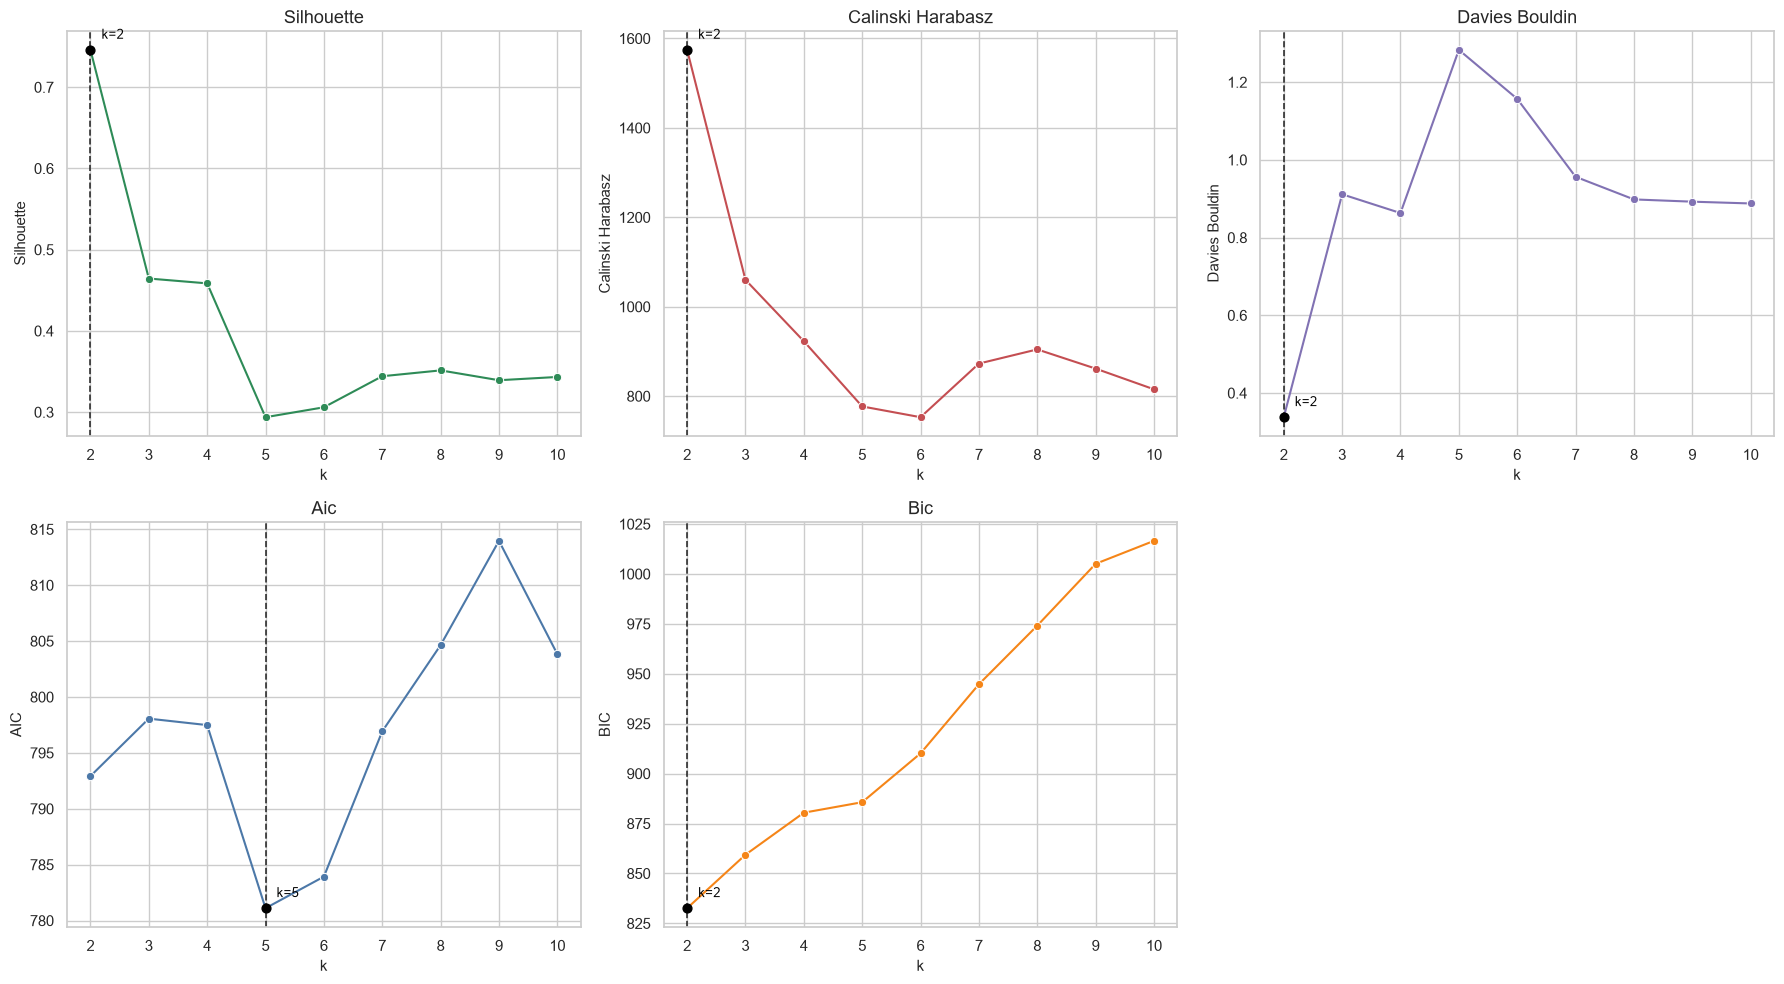

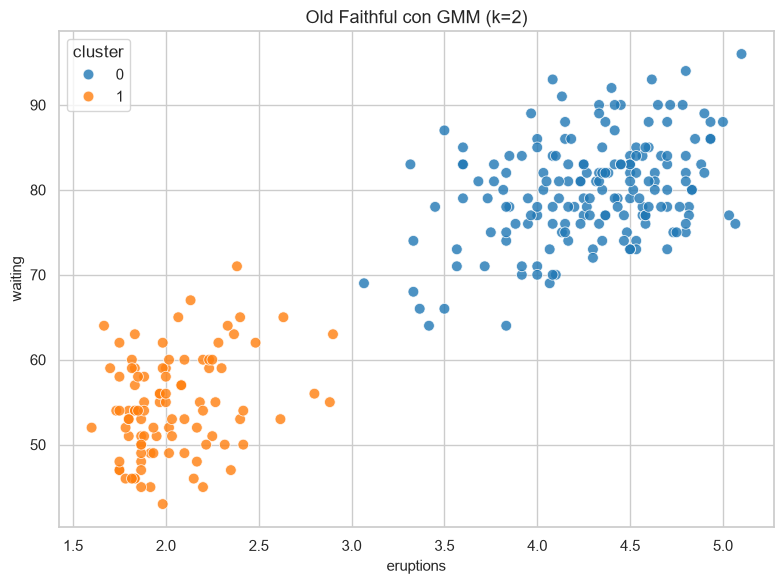

In [37]:
resultados_k_geyser = []

for k in RANGO_K:
    modelo_geyser = GaussianMixture(n_components=k, random_state=SEMILLA)
    etiquetas_geyser = modelo_geyser.fit_predict(X_geyser)
    metricas = evaluar_clustering(X_geyser, etiquetas_geyser)
    resultados_k_geyser.append({
        'k': k,
        'aic': modelo_geyser.aic(X_geyser),
        'bic': modelo_geyser.bic(X_geyser),
        **metricas,
    })

resultados_k_geyser = pd.DataFrame(resultados_k_geyser)
display(resultados_k_geyser.round(4))

seleccion_geyser = interpretar_seleccion_k(resultados_k_geyser, 'Old Faithful')
mejor_k_aic = seleccion_geyser['aic']
mejor_k_bic = seleccion_geyser['bic']
mejor_k_geyser = mejor_k_bic

print(f'\nElección pedagógica para Old Faithful: se usa BIC como criterio principal y se toma k={mejor_k_geyser}.')
print('En este caso, la intuición visual y la evidencia estadística coinciden: dos componentes describen bien la estructura del sistema.')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, metrica in [
    (axes[0, 0], 'silhouette'),
    (axes[0, 1], 'calinski_harabasz'),
    (axes[0, 2], 'davies_bouldin'),
    (axes[1, 0], 'aic'),
    (axes[1, 1], 'bic')
]:
    if metrica in ['silhouette', 'calinski_harabasz']:
        mejor_k_metrica = int(resultados_k_geyser.loc[resultados_k_geyser[metrica].idxmax(), 'k'])
    else:
        mejor_k_metrica = int(resultados_k_geyser.loc[resultados_k_geyser[metrica].idxmin(), 'k'])

    sns.lineplot(data=resultados_k_geyser, x='k', y=metrica, marker='o', ax=ax, color={'silhouette': '#2e8b57', 'calinski_harabasz': '#c44e52', 'davies_bouldin': '#8172b3', 'aic': '#4c78a8', 'bic': '#f58518'}[metrica])
    valor = float(resultados_k_geyser.loc[resultados_k_geyser['k'] == mejor_k_metrica, metrica].iloc[0])
    ax.axvline(mejor_k_metrica, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.scatter([mejor_k_metrica], [valor], color='black', s=40, zorder=5)
    ax.annotate(f'k={mejor_k_metrica}', xy=(mejor_k_metrica, valor), xytext=(8, 8), textcoords='offset points', fontsize=9, color='black')
    ax.set_title(metrica.replace('_', ' ').title())
    ax.set_xlabel('k')
    ax.set_ylabel(metrica.upper() if metrica in ['aic', 'bic'] else metrica.replace('_', ' ').title())

axes[1, 2].axis('off')
plt.tight_layout()

modelo_geyser = GaussianMixture(n_components=mejor_k_geyser, random_state=SEMILLA)
etiquetas_geyser = modelo_geyser.fit_predict(X_geyser)
perfil_geyser = resumir_clusters(geyser_numerico, etiquetas_geyser)

print('Perfil promedio por cluster en Old Faithful:')
display(perfil_geyser)

print('\nInterpretación del resultado:')
print('- El patrón esperado de Old Faithful es un comportamiento bimodal: erupciones cortas con espera corta y erupciones largas con espera larga.')
print('- GMM captura esa estructura como dos densidades gaussianas con distinta ubicación y dispersión.')
print('- El hecho de que BIC favorezca k=2 es una señal de que esa partición es relativamente parsimonia y muy informativa para los datos.')

graficar_resultados_2d(geyser_numerico, etiquetas_geyser, 'eruptions', 'waiting', f'Old Faithful con GMM (k={mejor_k_geyser})')


### Conclusiones de Old Faithful

Old Faithful es un caso muy claro de estructura bimodal. En la práctica, la distribución de los datos muestra dos regiones bien diferenciadas: una asociada a erupciones cortas con tiempos de espera cortos y otra a erupciones largas con tiempos de espera largos. GMM captura esa estructura como una mezcla de dos distribuciones gaussianas con distintas localizaciones y dispersiones.

La parte más valiosa de este ejemplo no es solo que “se vea” la separación, sino que la evidencia estadística confirma que dos componentes son la solución más parsimoniosa y más informativa. Esta coincidencia entre intuición, visualización y criterio BIC hace que Old Faithful sea un ejemplo especialmente apropiado para enseñar clustering con GMM en un curso de IA.


## 7. Wholesale Customers: tercer ejemplo clásico de clustering

Wholesale Customers es un dataset clásico de UCI sobre clientes de un distribuidor mayorista. Incluye el gasto anual en seis categorías de productos y es muy útil para ilustrar segmentación de clientes con GMM.

Fuente web consultada:
- UCI: https://archive.ics.uci.edu/dataset/292/wholesale+customers


,dataset,fuente,observaciones,variables_modelo,variables_totales
0,Wholesale Customers,UCI,440,6,7


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


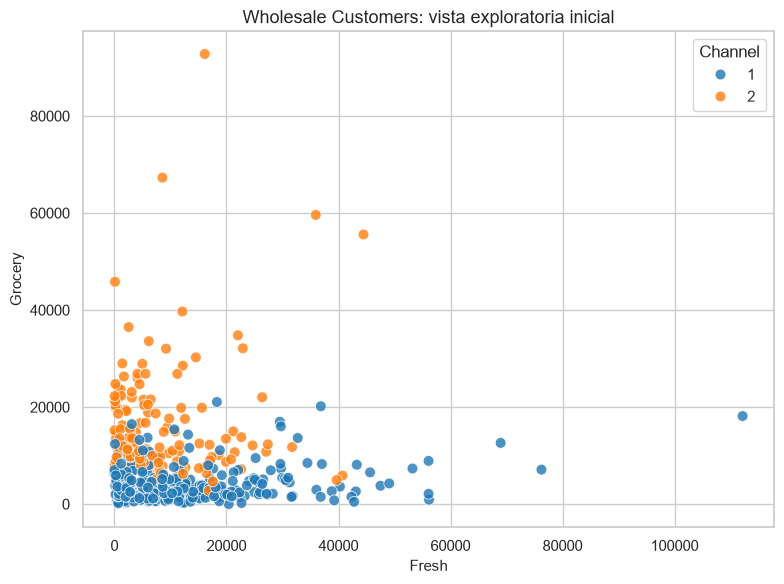

In [38]:
from ucimlrepo import fetch_ucirepo

wholesale = fetch_ucirepo(id=292)
wholesale_X = wholesale.data.features.copy()
wholesale_y = wholesale.data.targets.copy()

columnas_modelo = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
wholesale_numerico = wholesale_X[columnas_modelo].copy()

conteo_wholesale = pd.DataFrame({
    'dataset': ['Wholesale Customers'],
    'fuente': ['UCI'],
    'observaciones': [wholesale_X.shape[0]],
    'variables_modelo': [wholesale_numerico.shape[1]],
    'variables_totales': [wholesale_X.shape[1]],
})

display(conteo_wholesale)
display(wholesale_X.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_X, x='Fresh', y='Grocery', hue='Channel', palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title('Wholesale Customers: vista exploratoria inicial')
plt.tight_layout()

### Preparación y evaluación para Wholesale Customers

Para este conjunto usamos una transformación logarítmica suave sobre las variables de gasto y después estandarizamos. Esto reduce la asimetría de los montos y hace que GMM trabaje con densidades más equilibradas. En datos comerciales, este paso es importante porque los valores de gasto suelen seguir distribuciones muy sesgadas: unas pocas compras grandes pueden dominar la escala si no se transforman.

El objetivo pedagógico es mostrar que la preparación de los datos no es un detalle técnico menor: si el conjunto tiene asimetría y valores de diferentes magnitudes, una mala escala puede deformar la comparación entre componentes y esconder grupos relevantes.


Variables de gasto transformadas con log1p y estandarizadas.


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


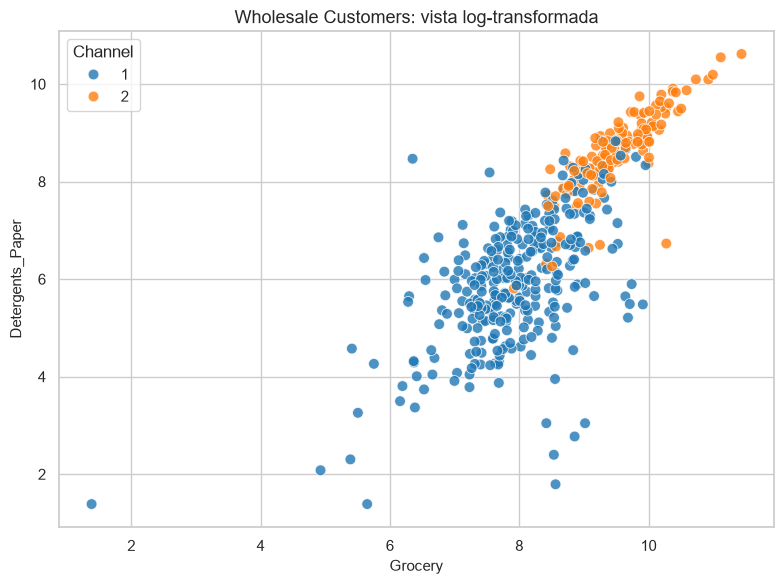

In [39]:
wholesale_log = np.log1p(wholesale_numerico)
scaler_wholesale = StandardScaler()
X_wholesale = scaler_wholesale.fit_transform(wholesale_log)
X_wholesale_df = pd.DataFrame(X_wholesale, columns=columnas_modelo)

print('Variables de gasto transformadas con log1p y estandarizadas.')
display(X_wholesale_df.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_log, x='Grocery', y='Detergents_Paper', hue=wholesale_X['Channel'], palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title('Wholesale Customers: vista log-transformada')
plt.tight_layout()


### Selección de k y lectura de negocio

Buscamos el mejor $k$ con varias métricas internas y luego analizamos la composición de los clusters respecto a `Channel` y `Region`.


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,2,6209.5890,6434.3616,0.2656,165.4197,1.3908
1,3,6103.2816,6442.4839,0.1057,78.1200,2.0073
2,4,5863.4829,6317.1149,0.1738,80.7031,2.3953
3,5,5862.4660,6430.5277,0.1507,60.7202,2.4783
4,6,5862.4991,6544.9904,0.1780,58.7541,2.2310
5,7,5841.2312,6638.1523,0.1347,49.6823,2.5470
6,8,5776.3913,6687.7421,0.1384,54.8241,2.0059
7,9,5790.6823,6816.4628,0.1159,56.1251,1.9586
8,10,5740.1479,6880.3580,0.1239,51.0944,1.8135



Dataset: Wholesale Customers
- BIC recomienda k=4
- AIC recomienda k=10
- Silhouette recomienda k=2
- Calinski-Harabasz recomienda k=2
- Davies-Bouldin recomienda k=2
- Interpretación: en GMM, BIC suele ser la regla principal porque penaliza la complejidad del modelo. AIC, aunque útil como referencia, tiende a favorecer soluciones más complejas. Las métricas internas ayudan a describir la calidad de la separación, pero no sustituyen la elección estadística basada en el criterio de información.

Elección pedagógica para Wholesale: se usa BIC como criterio principal y se toma k=4.
Esto evita que la solución final sea impulsada por una métrica que favorece modelos demasiado complejos o por una separación artificial en el plano.

Interpretación de la selección de k para Wholesale:
- Silhouette y Calinski-Harabasz favorecen un número de grupos distinto; esta señal sugiere que la separación visual no siempre coincide con la parsimonia del modelo.
- AIC tiende a escoger una solución más comp

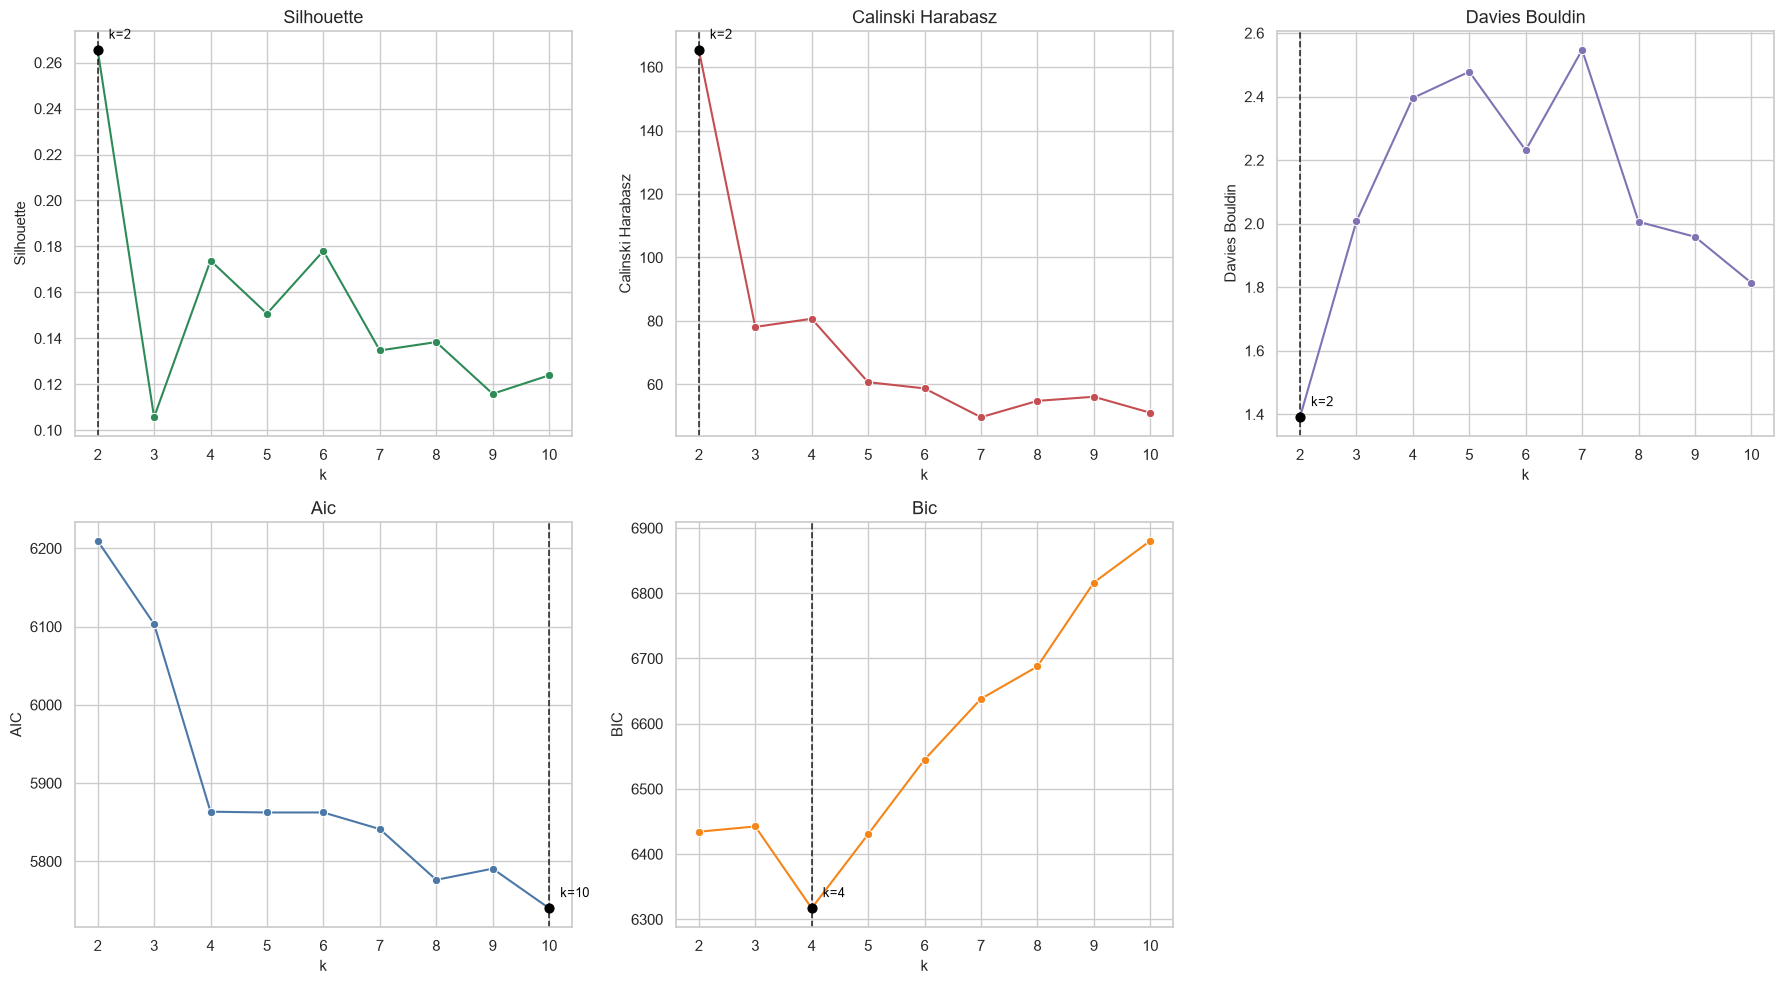

In [40]:
resultados_k_wholesale = []

for k in RANGO_K:
    modelo_wholesale = GaussianMixture(n_components=k, random_state=SEMILLA)
    etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)
    metricas = evaluar_clustering(X_wholesale, etiquetas_wholesale)
    resultados_k_wholesale.append({
        'k': k,
        'aic': modelo_wholesale.aic(X_wholesale),
        'bic': modelo_wholesale.bic(X_wholesale),
        **metricas,
    })

resultados_k_wholesale = pd.DataFrame(resultados_k_wholesale)
display(resultados_k_wholesale.round(4))

seleccion_wholesale = interpretar_seleccion_k(resultados_k_wholesale, 'Wholesale Customers')
mejor_k_aic = seleccion_wholesale['aic']
mejor_k_bic = seleccion_wholesale['bic']
mejor_k_wholesale = mejor_k_bic

print(f'\nElección pedagógica para Wholesale: se usa BIC como criterio principal y se toma k={mejor_k_wholesale}.')
print('Esto evita que la solución final sea impulsada por una métrica que favorece modelos demasiado complejos o por una separación artificial en el plano.')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metric_colors = {
    'silhouette': '#2e8b57',
    'calinski_harabasz': '#c44e52',
    'davies_bouldin': '#8172b3',
    'aic': '#4c78a8',
    'bic': '#f58518',
}

for ax, metrica in [
    (axes[0, 0], 'silhouette'),
    (axes[0, 1], 'calinski_harabasz'),
    (axes[0, 2], 'davies_bouldin'),
    (axes[1, 0], 'aic'),
    (axes[1, 1], 'bic')
]:
    if metrica in ['silhouette', 'calinski_harabasz']:
        mejor_k_metrica = int(resultados_k_wholesale.loc[resultados_k_wholesale[metrica].idxmax(), 'k'])
    else:
        mejor_k_metrica = int(resultados_k_wholesale.loc[resultados_k_wholesale[metrica].idxmin(), 'k'])

    sns.lineplot(data=resultados_k_wholesale, x='k', y=metrica, marker='o', ax=ax, color=metric_colors[metrica])
    valor = float(resultados_k_wholesale.loc[resultados_k_wholesale['k'] == mejor_k_metrica, metrica].iloc[0])
    ax.axvline(mejor_k_metrica, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.scatter([mejor_k_metrica], [valor], color='black', s=40, zorder=5)
    ax.annotate(f'k={mejor_k_metrica}', xy=(mejor_k_metrica, valor), xytext=(8, 8), textcoords='offset points', fontsize=9, color='black')
    ax.set_title(metrica.replace('_', ' ').title())
    ax.set_xlabel('k')
    ax.set_ylabel(metrica.upper() if metrica in ['aic', 'bic'] else metrica.replace('_', ' ').title())

axes[1, 2].axis('off')
plt.tight_layout()

print('\nInterpretación de la selección de k para Wholesale:')
print(f'- Silhouette y Calinski-Harabasz favorecen un número de grupos distinto; esta señal sugiere que la separación visual no siempre coincide con la parsimonia del modelo.')
print(f'- AIC tiende a escoger una solución más compleja, mientras que BIC penaliza esa complejidad y por eso se usa como criterio principal para GMM.')
print(f'- En este caso, BIC elige k={mejor_k_wholesale}, y esa decisión es la que se usa para construir los perfiles finales de cluster.')


In [41]:
mejor_k_wholesale = mejor_k_bic

In [42]:
modelo_wholesale = GaussianMixture(n_components=mejor_k_wholesale, random_state=SEMILLA)
etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)

wholesale_resultados = wholesale_X.copy()
wholesale_resultados['cluster'] = etiquetas_wholesale

for col in ['Region', 'Channel']:
    if col in wholesale_X.columns:
        wholesale_resultados[col] = wholesale_X[col]
    elif hasattr(wholesale, 'data') and hasattr(wholesale.data, 'features') and col in wholesale.data.features.columns:
        wholesale_resultados[col] = wholesale.data.features[col]

perfil_wholesale = wholesale_resultados.groupby('cluster')[columnas_modelo].mean().round(2)
cluster_channel = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Channel']) if 'Channel' in wholesale_resultados.columns else None
cluster_region = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Region']) if 'Region' in wholesale_resultados.columns else None

print('Perfil promedio por cluster usando el mejor k por BIC:')
display(perfil_wholesale)
if cluster_channel is not None:
    print('Cruce cluster vs Channel:')
    display(cluster_channel)
if cluster_region is not None:
    print('Cruce cluster vs Region:')
    display(cluster_region)

print('\nInterpretación del perfil final:')
for cluster_id in sorted(perfil_wholesale.index):
    fila = perfil_wholesale.loc[cluster_id]
    if cluster_channel is not None and cluster_region is not None:
        canal_predominante = cluster_channel.loc[cluster_id].idxmax()
        region_predominante = cluster_region.loc[cluster_id].idxmax()
        print(f'- Cluster {cluster_id}: destaca por {fila.idxmax()} y se concentra sobre todo en el canal {canal_predominante} y en la región {region_predominante}.')
    elif cluster_channel is not None:
        canal_predominante = cluster_channel.loc[cluster_id].idxmax()
        print(f'- Cluster {cluster_id}: destaca por {fila.idxmax()} y se concentra sobre todo en el canal {canal_predominante}.')
    elif cluster_region is not None:
        region_predominante = cluster_region.loc[cluster_id].idxmax()
        print(f'- Cluster {cluster_id}: destaca por {fila.idxmax()} y se concentra sobre todo en la región {region_predominante}.')
    else:
        print(f'- Cluster {cluster_id}: destaca por {fila.idxmax()} y su perfil es principalmente de consumo en esa categoría.')

print('\nConclusión: la solución final con k=' + str(mejor_k_wholesale) + ' es la elegida por el criterio BIC, que penaliza la complejidad del modelo y hace más interpretables los grupos para un ejemplo de negocio.')


Perfil promedio por cluster usando el mejor k por BIC:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,4439.37,9389.43,15917.48,691.67,7482.90,1166.31
1,14946.10,3103.06,3206.00,4428.09,532.72,1345.44
2,11193.06,9697.00,14032.99,1811.73,6060.99,1973.79
3,10991.50,4730.88,5534.33,2949.56,501.67,1849.87


Cruce cluster vs Channel:


Channel,1,2
cluster,,
0,11,56
1,211,7
2,26,77
3,50,2



Interpretación del perfil final:
- Cluster 0: destaca por Grocery y se concentra sobre todo en el canal 2.
- Cluster 1: destaca por Fresh y se concentra sobre todo en el canal 1.
- Cluster 2: destaca por Grocery y se concentra sobre todo en el canal 2.
- Cluster 3: destaca por Fresh y se concentra sobre todo en el canal 1.

Conclusión: la solución final con k=4 es la elegida por el criterio BIC, que penaliza la complejidad del modelo y hace más interpretables los grupos para un ejemplo de negocio.


In [43]:
modelo_wholesale = GaussianMixture(n_components=mejor_k_wholesale, random_state=SEMILLA)
etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)

wholesale_resultados = wholesale_X.copy()
wholesale_resultados['cluster'] = etiquetas_wholesale

for col in ['Region', 'Channel']:
    if col in wholesale_X.columns:
        wholesale_resultados[col] = wholesale_X[col]
    elif hasattr(wholesale, 'data') and hasattr(wholesale.data, 'features') and col in wholesale.data.features.columns:
        wholesale_resultados[col] = wholesale.data.features[col]

perfil_wholesale = wholesale_resultados.groupby('cluster')[columnas_modelo].mean().round(2)
cluster_channel = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Channel']) if 'Channel' in wholesale_resultados.columns else None
cluster_region = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Region']) if 'Region' in wholesale_resultados.columns else None

print('Perfil promedio por cluster:')
display(perfil_wholesale)
if cluster_channel is not None:
    print('Cruce cluster vs Channel:')
    display(cluster_channel)
if cluster_region is not None:
    print('Cruce cluster vs Region:')
    display(cluster_region)


Perfil promedio por cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,4439.37,9389.43,15917.48,691.67,7482.90,1166.31
1,14946.10,3103.06,3206.00,4428.09,532.72,1345.44
2,11193.06,9697.00,14032.99,1811.73,6060.99,1973.79
3,10991.50,4730.88,5534.33,2949.56,501.67,1849.87


Cruce cluster vs Channel:


Channel,1,2
cluster,,
0,11,56
1,211,7
2,26,77
3,50,2


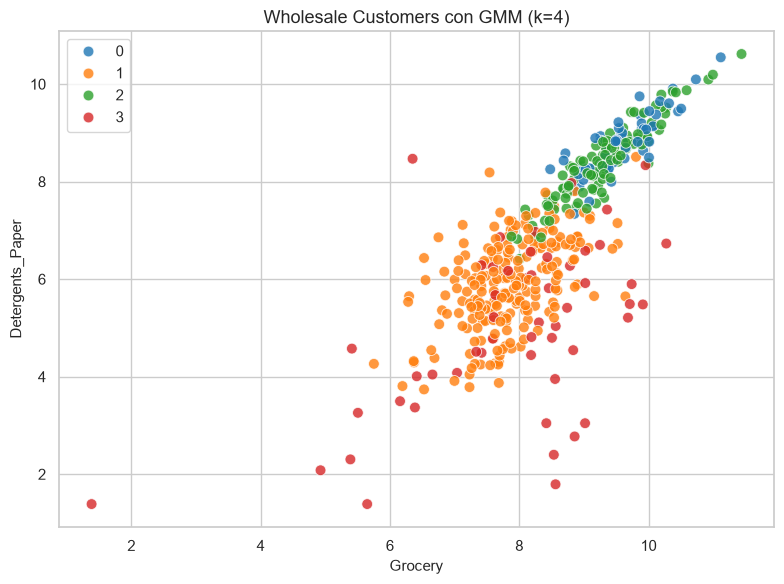

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_log, x='Grocery', y='Detergents_Paper', hue=etiquetas_wholesale, palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title(f'Wholesale Customers con GMM (k={mejor_k_wholesale})')
plt.tight_layout()


### Conclusiones de Wholesale Customers

Wholesale Customers es un ejemplo más empresarial y más cercano a la práctica analítica. Aquí la estructura no es tan visualmente nítida como en Old Faithful, pero la segmentación aún resulta muy útil: GMM revela perfiles de compra distintos asociados a distintos patrones de gasto en categorías como Fresh, Grocery, Milk y Detergents_Paper.

La interpretación más importante aquí es que el clustering no solo produce etiquetas; también organiza la información en perfiles comprensibles. Un segmento puede estar dominado por consumo de productos frescos, mientras que otro se distingue por compras de productos de limpieza o de almacén. Esa capacidad para resumir comportamiento de clientes en perfiles cuantitativos es precisamente una de las razones por las que GMM es relevante en contextos reales.

En este caso, la elección de $k$ por BIC aporta rigor: evita aceptar soluciones demasiado complejas que no se justifican por la estructura real de los datos, y permite que la interpretación final se apoye en una partición estadísticamente más estable.


## Revisión metodológica: selección de k en GMM

Para modelos de mezcla gaussiana, la elección del número de componentes debe hacerse con cuidado. Las métricas internas y los criterios de información no son equivalentes: cada una responde a una pregunta distinta.

- Silhouette mide qué tan bien separados están los grupos.
- Calinski-Harabasz evalúa la proporción entre separación entre clusters y dispersión intra-cluster.
- Davies-Bouldin resume compactación y separación en un único índice.
- AIC y BIC comparan la capacidad de ajuste del modelo con su complejidad.

En la práctica, para GMM el criterio dominante suele ser BIC. Esto se debe a que BIC penaliza la introducción de componentes adicionales más fuertemente que AIC, lo que evita soluciones demasiado grandes cuando la estructura real de los datos es más simple. La elección final de $k$ no debe buscar el modelo más complicado, sino el más explicativo y parsimonioso que describa bien la organización observada.

Este punto es especialmente importante en un contexto pedagógico: si el estudiante se concentra solo en la apariencia del gráfico, puede llegar a la conclusión equivocada de que “más grupos es mejor”. En GMM, la calidad del ajuste no debe medirse solo por la complejidad del modelo, sino por la relación entre estructura observada, capacidad explicativa y penalización de la complejidad.



Dataset: iris
  Mejor k por BIC: 2
  Mejor k por AIC: 7
  Elección final para GMM: 2 (criterio BIC)


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,2,707.4006,794.7090,0.5818,251.3493,0.5933
1,3,708.7226,841.1905,0.4751,141.2315,0.8867
2,4,671.6734,849.3009,0.2310,138.8946,1.3220
3,5,678.7507,901.5377,0.1729,127.1599,1.3302
4,6,700.6620,968.6086,0.1899,138.1896,1.3843
5,7,642.1531,955.2592,0.0653,84.3716,1.7031
6,8,667.8037,1026.0693,0.1740,105.1888,1.4811
7,9,725.9263,1129.3514,0.2645,148.3064,1.0918
8,10,651.8233,1100.4080,0.1532,106.4591,1.4912


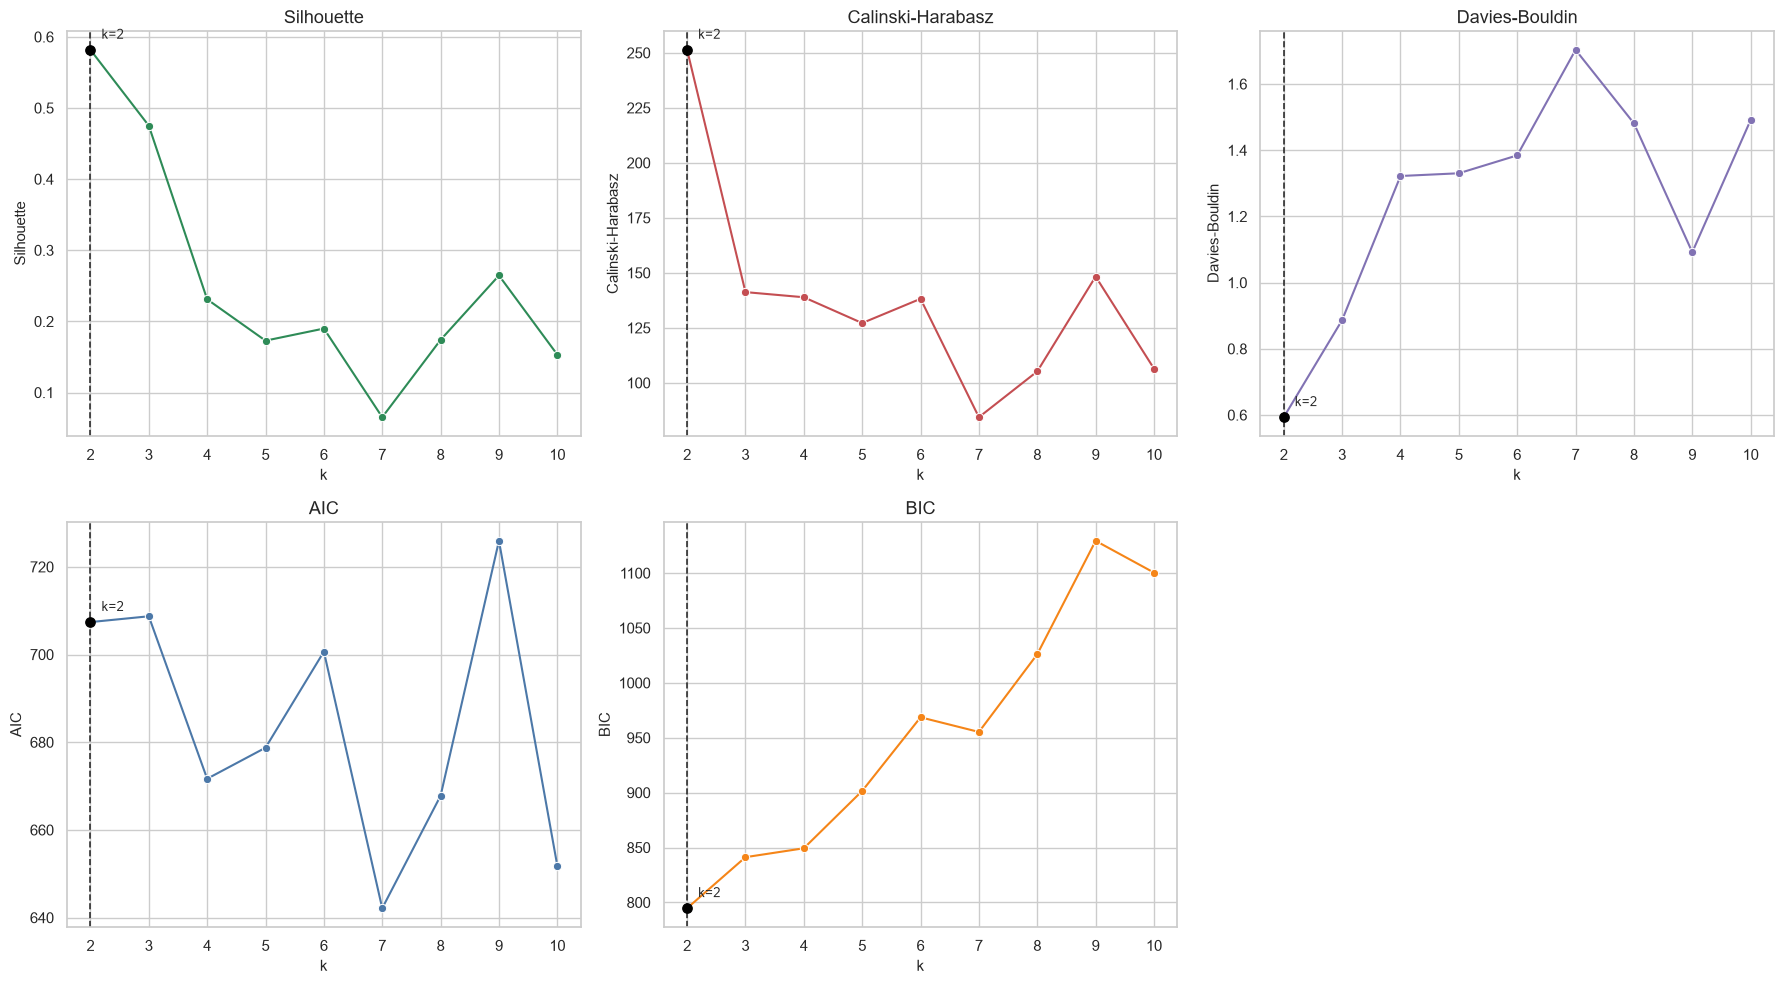


Dataset: wholesale
  Mejor k por BIC: 4
  Mejor k por AIC: 10
  Elección final para GMM: 4 (criterio BIC)


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,2,6209.5890,6434.3616,0.2656,165.4197,1.3908
1,3,6103.2816,6442.4839,0.1057,78.1200,2.0073
2,4,5863.4829,6317.1149,0.1738,80.7031,2.3953
3,5,5862.4660,6430.5277,0.1507,60.7202,2.4783
4,6,5862.4991,6544.9904,0.1780,58.7541,2.2310
5,7,5841.2312,6638.1523,0.1347,49.6823,2.5470
6,8,5776.3913,6687.7421,0.1384,54.8241,2.0059
7,9,5790.6823,6816.4628,0.1159,56.1251,1.9586
8,10,5740.1479,6880.3580,0.1239,51.0944,1.8135


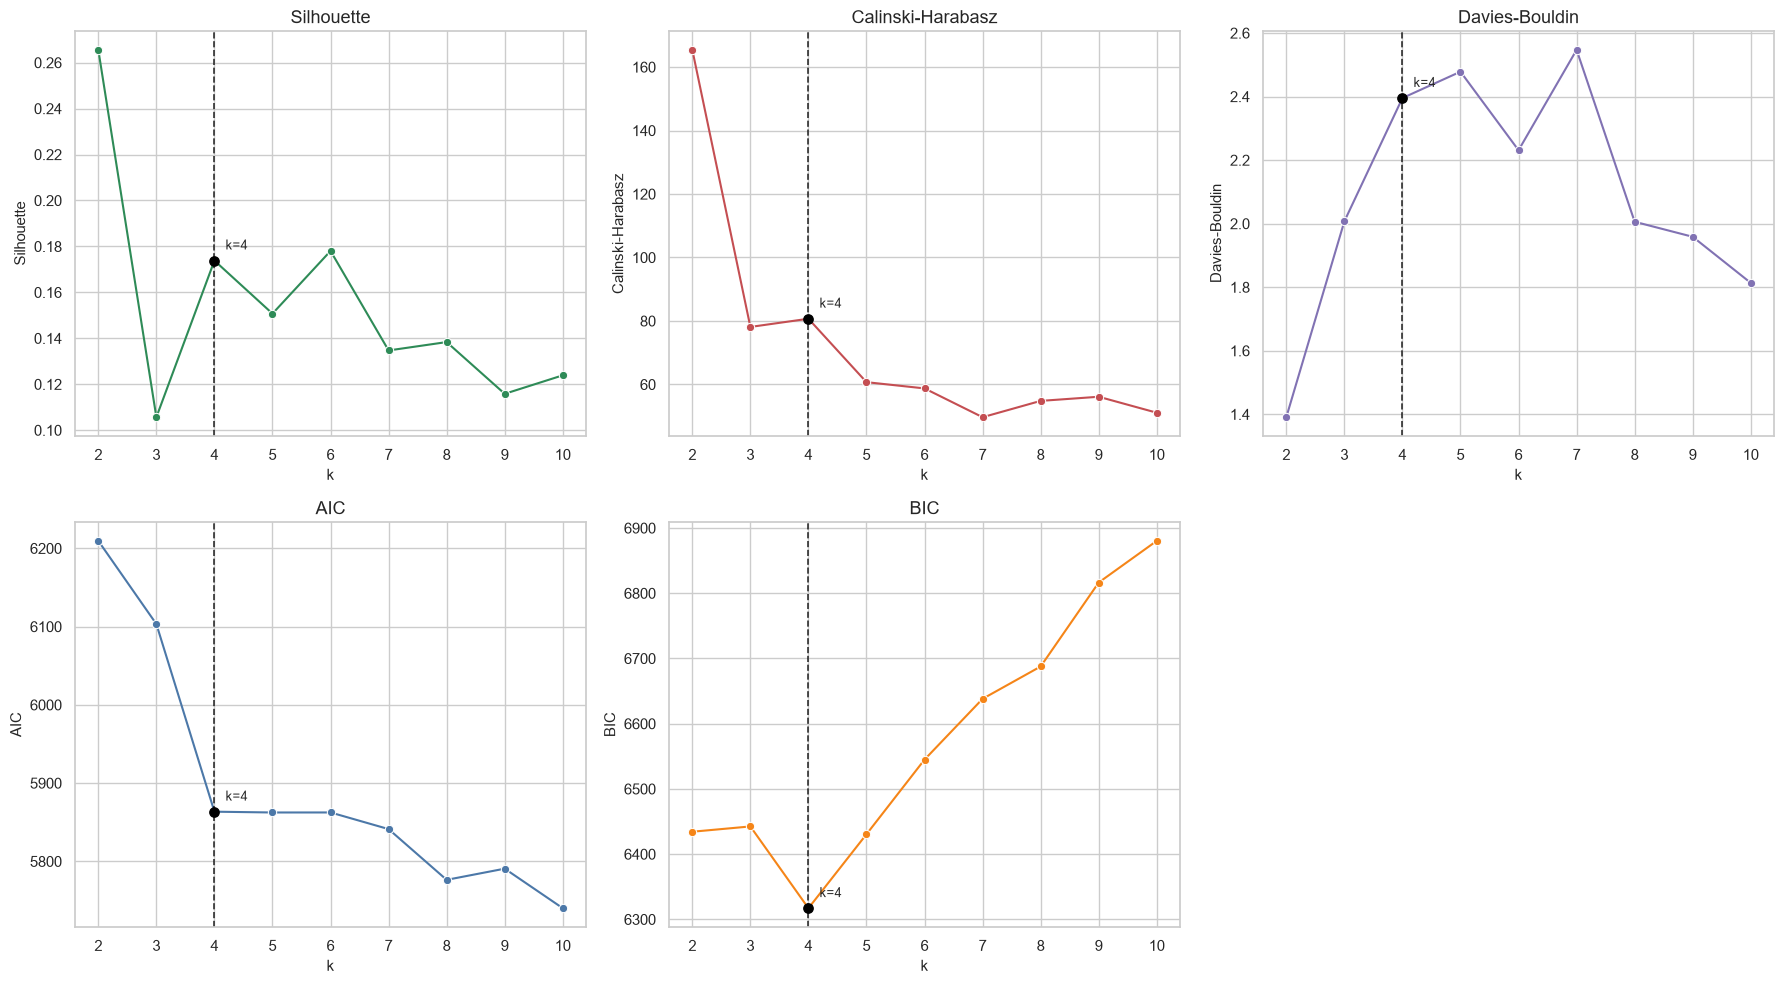

In [45]:
# Revisión final: criterio principal para GMM
# BIC decide k; AIC se reporta solo como referencia

for label, X_data, results in [
    ('iris', X_scaled, resultados_k),
    ('wholesale', X_wholesale, resultados_k_wholesale),
]:
    if results is None or results.empty:
        continue

    mejor_k_aic = int(results.loc[results['aic'].idxmin(), 'k'])
    mejor_k_bic = int(results.loc[results['bic'].idxmin(), 'k'])
    mejor_k = mejor_k_bic

    print(f'\nDataset: {label}')
    print(f'  Mejor k por BIC: {mejor_k_bic}')
    print(f'  Mejor k por AIC: {mejor_k_aic}')
    print(f'  Elección final para GMM: {mejor_k} (criterio BIC)')
    display(results[['k', 'aic', 'bic', 'silhouette', 'calinski_harabasz', 'davies_bouldin']].round(4))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    metrics = [
        ('silhouette', '#2e8b57', 'Silhouette'),
        ('calinski_harabasz', '#c44e52', 'Calinski-Harabasz'),
        ('davies_bouldin', '#8172b3', 'Davies-Bouldin'),
        ('aic', '#4c78a8', 'AIC'),
        ('bic', '#f58518', 'BIC'),
    ]

    for ax, (metric, color, title) in zip(axes.flat, metrics):
        sns.lineplot(data=results, x='k', y=metric, marker='o', ax=ax, color=color)
        ax.axvline(mejor_k, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
        val = float(results.loc[results['k'] == mejor_k, metric].iloc[0])
        ax.scatter([mejor_k], [val], color='black', s=45, zorder=5)
        ax.annotate(f'k={mejor_k}', xy=(mejor_k, val), xytext=(8, 8), textcoords='offset points', fontsize=9)
        ax.set_title(title)
        ax.set_xlabel('k')
        ax.set_ylabel(title)

    axes[1, 2].axis('off')
    plt.tight_layout()
    plt.show()
